Decision Tree

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


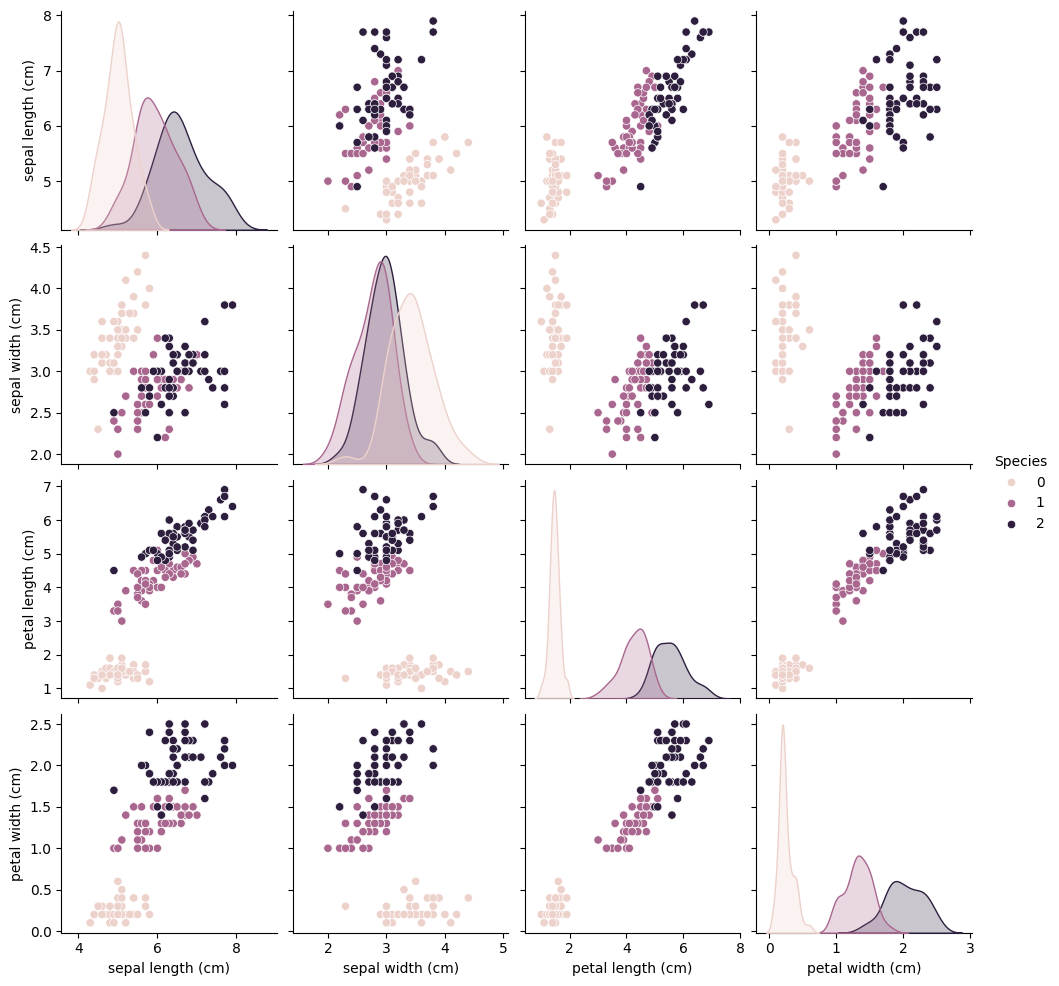

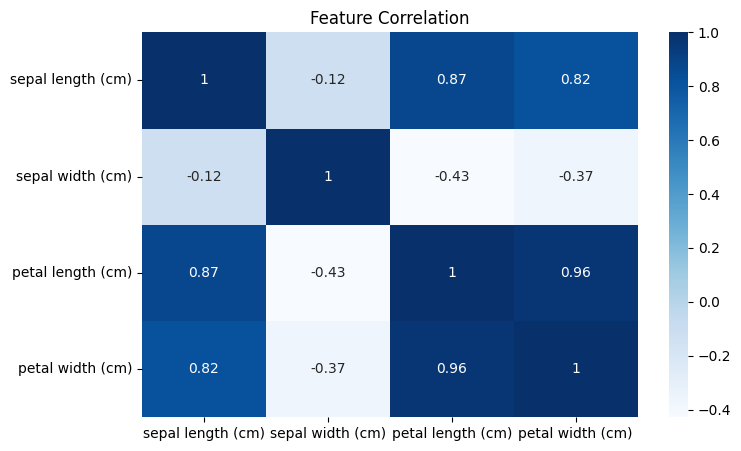

Model Trained


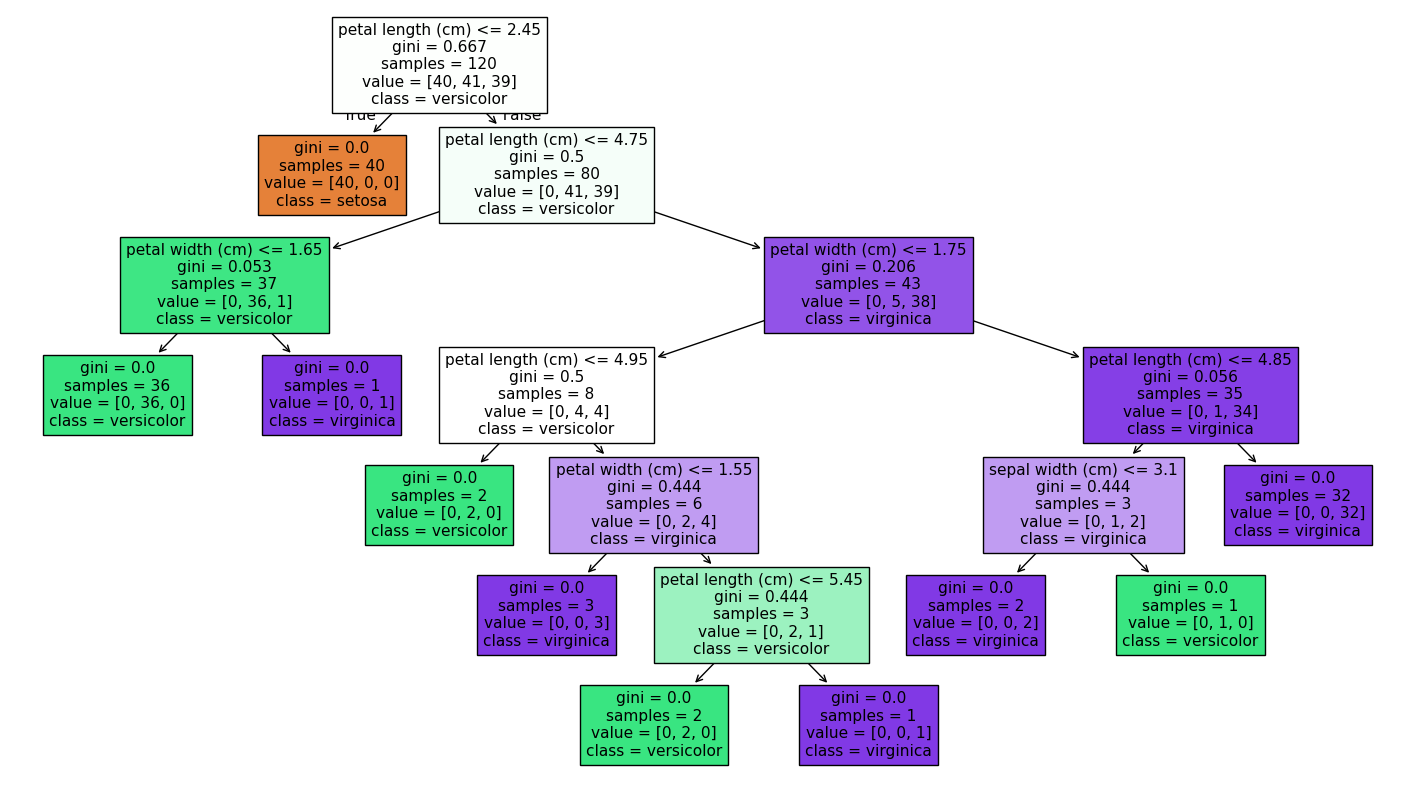

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy
1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


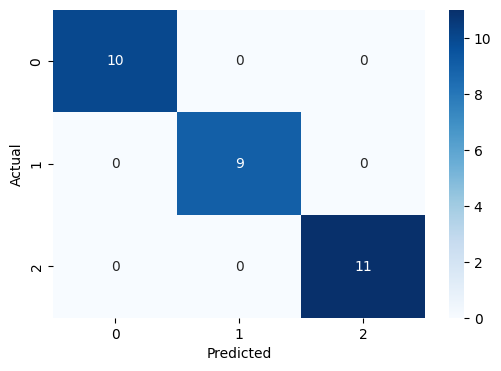

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

             Feature  Importance
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.016670
2  petal length (cm)    0.906143
3   petal width (cm)    0.077186


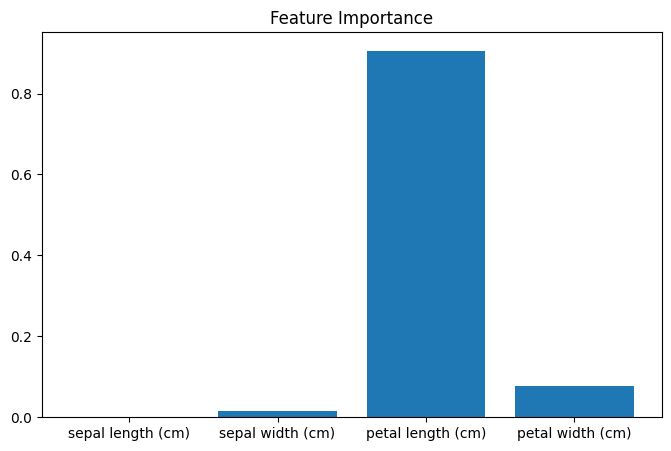

1 0.6333333333333333
2 0.9666666666666667
3 1.0
4 1.0
5 1.0
6 1.0


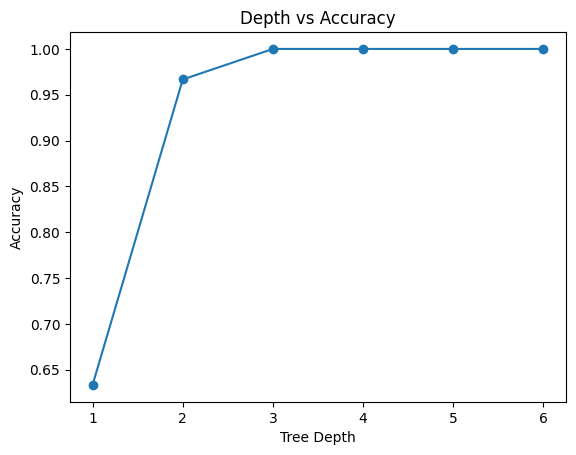

1.0
[0]
Decision Tree Completed Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [9]:
# ============================================================
# LOAD DATASET
# ============================================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

print(X.head())

# ============================================================
# DATA VISUALIZATION
# ============================================================

sns.pairplot(
    pd.concat(
        [X, pd.DataFrame({"Species":y})],
        axis=1
    ),
    hue="Species"
)

plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")

plt.show()

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# MODEL TRAINING
# ============================================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=9,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained")

# ============================================================
# TREE VISUALIZATION
# ============================================================

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)

plt.show()

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)

print(y_pred)

# ============================================================
# ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy")

print(accuracy)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

print(importance)

# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

# ============================================================
# DEPTH COMPARISON
# ============================================================

depths = [1,2,3,4,5,6]

scores = []

for depth in depths:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(
        X_train,
        y_train
    )

    score = dt.score(
        X_test,
        y_test
    )

    scores.append(score)

    print(
        depth,
        score
    )

plt.plot(
    depths,
    scores,
    marker="o"
)

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Depth vs Accuracy")

plt.show()

# ============================================================
# ENTROPY TREE
# ============================================================

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=9
)

entropy_tree.fit(
    X_train,
    y_train
)

print(
    entropy_tree.score(
        X_test,
        y_test
    )
)

# ============================================================
# NEW PREDICTION
# ============================================================

prediction = model.predict([
    [5.1,3.5,1.4,0.2]
])

print(prediction)

print("Decision Tree Completed Successfully")